# API Basics with Python and FastAPI

**Estimated time:** ~12 hours total (about 4 hours reading and running this guide + ~8 hours on `api-basics-exercises.ipynb`).

## Who This Is For

This tutorial is for you if you are comfortable with Python basics (functions, dicts, classes) and want to learn how web APIs work and how to build them. We use **FastAPI**, the most popular modern Python web framework.

## Prerequisites

- `python-basics` and `python-intermediate` materials (or equivalent knowledge)
- Python 3.10+ installed

## Setup

Install the packages used in this guide:

```
pip install fastapi uvicorn httpx requests
```

## How to use this guide

1. Read each explanation section — don't skip the diagrams, they show the "shape" of the idea.
2. Run the code cell below it and **read the printed output carefully**.
3. Change something small (a value, a URL, a type) and re-run to see what happens. Breaking things on purpose is the fastest way to learn.
4. When you finish, do `api-basics-exercises.ipynb`.

## How code runs in this notebook

A real API runs as a **server** that waits for requests. Inside a notebook we cannot easily keep a server running, so we use FastAPI's `TestClient`: it sends requests **directly to our app in memory**, exactly like a browser or another program would over the network. Everything you learn here works identically when you run the app for real with `uvicorn` (shown at the end).

## Part 1: What Is an API?

An **API** (Application Programming Interface) is a way for programs to talk to each other. A **web API** does this over HTTP — the same protocol your browser uses. One program (the **client**) sends a **request**; another (the **server**) sends back a **response**.

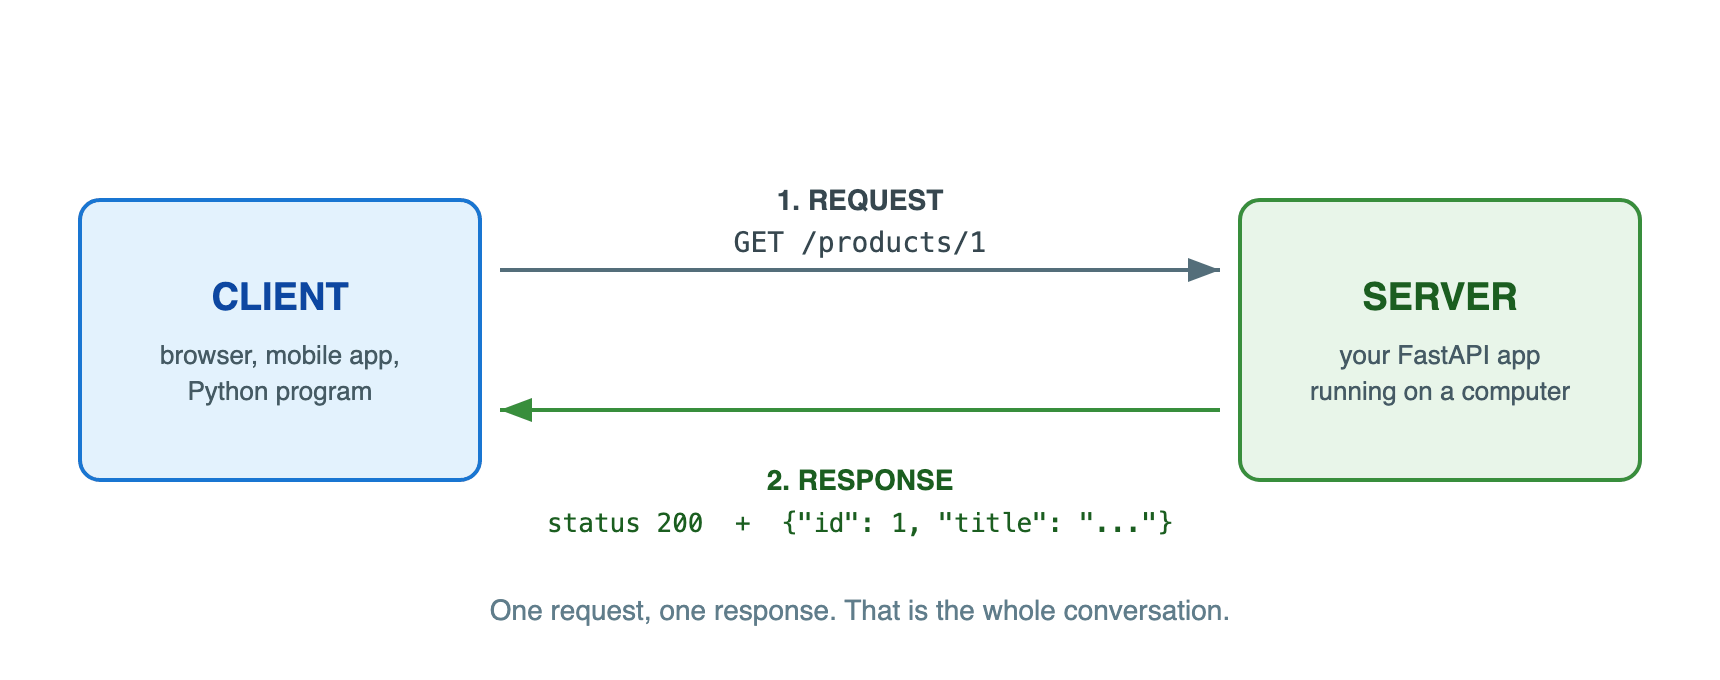

This picture is the whole model. Every interaction with every web API — Google Maps, Stripe payments, ChatGPT — is this same two-step dance:

1. **Client sends a request** — "I want something."
2. **Server sends a response** — "Here it is" (or "here's why I can't give it to you").

The server never contacts the client on its own. It just sits and waits for requests.

### Anatomy of a request: the URL

The first part of any request is **where to send it** — the URL. Every URL breaks into four parts:

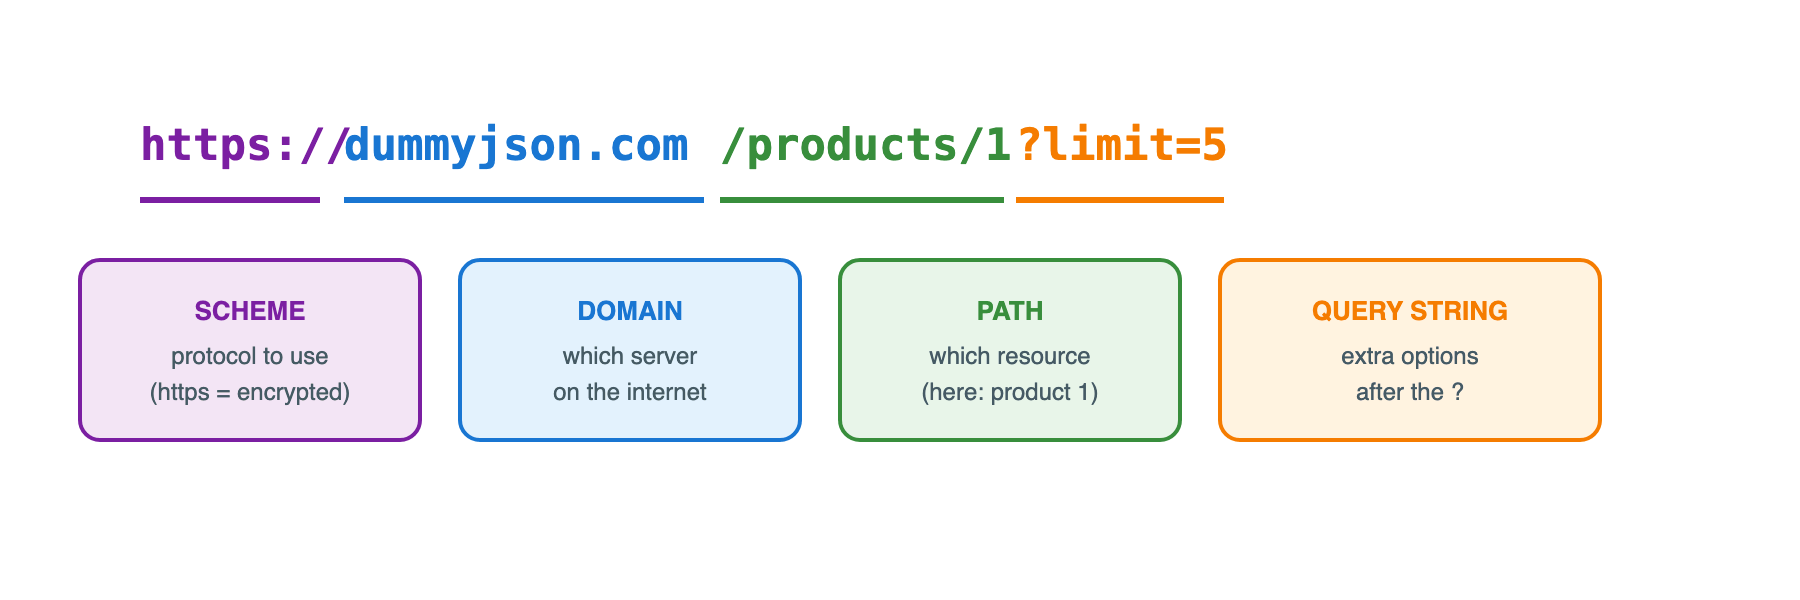

Try it right now: open [https://dummyjson.com/products/1](https://dummyjson.com/products/1) in your browser. You'll see raw data instead of a web page — you just made an API request. DummyJSON is a free fake online store we'll use for practice.

### Anatomy of a request: the method

The second part is **what you want to do**. HTTP has a small set of verbs, and APIs use four of them constantly:

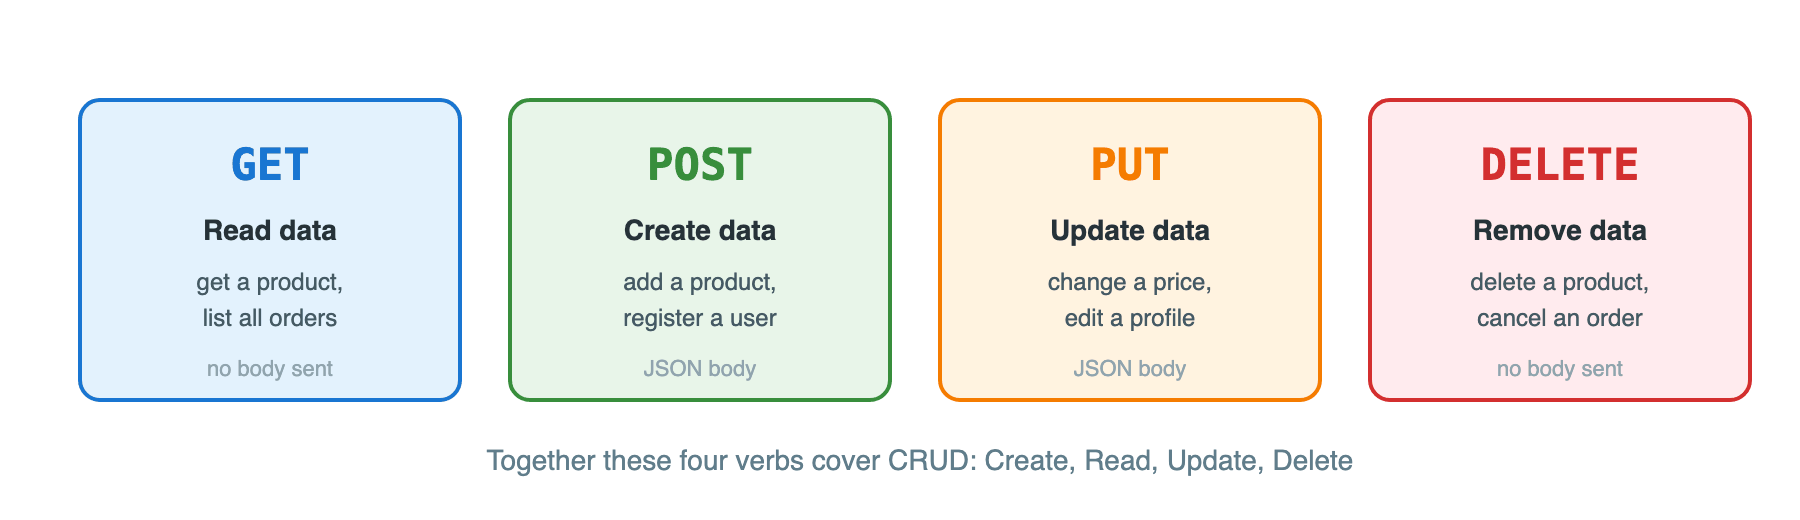

The same URL can behave differently with different methods: `GET /products/1` reads product 1, `DELETE /products/1` removes it.

### Anatomy of a response: the status code

Every response starts with a 3-digit **status code** — a machine-readable summary of how it went. You only need to remember the families:

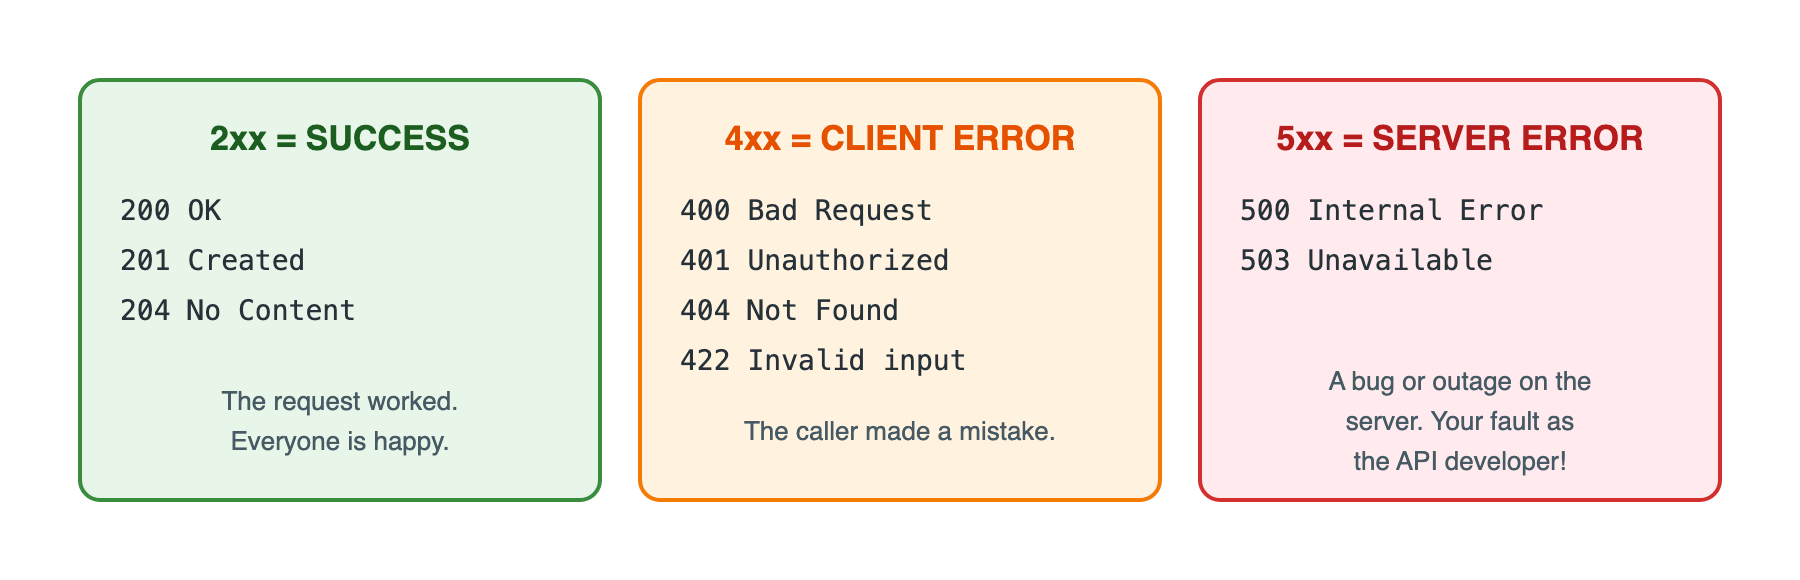

### The data format: JSON

Requests and responses carry data as **JSON** — plain text that looks almost exactly like Python dicts and lists. Let's get comfortable converting between the two, because you'll do it constantly:

In [ ]:
import json

# JSON is text. Python converts dicts/lists to and from it.
user = {"name": "Asha", "age": 25, "skills": ["python", "sql"]} #get the data in dict form

as_text = json.dumps(user)          # dict -> JSON string (what travels over the network)
print(type(as_text), as_text)

back = json.loads(as_text)          # JSON string -> dict
print(type(back), back["skills"])

**What just happened:** `json.dumps` ("dump to string") turned a dict into text that can travel over a network. `json.loads` ("load from string") turned it back. Notice the JSON text looks like Python — the differences are small (JSON uses `null`, `true`, `false` instead of `None`, `True`, `False`, and only double quotes).

## Part 2: Calling an API with `requests`

Before building APIs, let's **call** one — this is the client side. The `requests` library is Python's standard tool for it. We'll fetch a product from the DummyJSON fake store.

Step by step, the code below:

1. **Builds the URL** — `https://dummyjson.com/products/1` (domain + path identifying product 1).
2. **Sends a GET request** with `requests.get(...)` and waits for the response.
3. **Checks the status code** — is it 200 (success)?
4. **Parses the JSON body** with `.json()`, giving us a normal Python dict to work with.

(If you are offline this cell prints a message and you can move on — nothing later depends on it.)

In [1]:
import requests

try:
    # Step 2: send the request (timeout: give up after 5 seconds)
    response = requests.get("https://dummyjson.com/products/1", timeout=5)

    # Step 3: how did it go?
    print("Status code:", response.status_code)

    # Step 4: parse the JSON body into a dict
    product = response.json()
    print("Title:", product["title"])
    print("Price:", product["price"])
    print("Rating:", product["rating"])

    # Try a query parameter: only 3 products, see how the URL changes
    response = requests.get("https://dummyjson.com/products?limit=3", timeout=5)
    titles = [p["title"] for p in response.json()["products"]]
    print("First 3 products:", titles)
except requests.RequestException as e:
    print("No internet connection right now, skip this cell:", e)

ModuleNotFoundError: No module named 'requests'

**Things to try:** change the `1` to another number, change `limit=3` to `limit=10`, or request `https://dummyjson.com/products/99999` and look at the status code you get back (it should be 404 — the product doesn't exist).

For the rest of this guide we switch sides: **we become the server.**

## Part 3: Your First FastAPI App

A FastAPI app is built from three pieces. Read the code below with this checklist:

1. **`app = FastAPI()`** — creates the application object. This *is* your API; everything else attaches to it.
2. **`@app.get("/")`** — a decorator that says: *"when a GET request arrives at the path `/`, call the function below"*. This connecting-of-URL-to-function is called **routing**.
3. **`return {...}`** — whatever the function returns, FastAPI converts to JSON and wraps in a response automatically. You never build the response text by hand.

Here is the full journey of a request through FastAPI — keep this picture in mind for the whole guide:

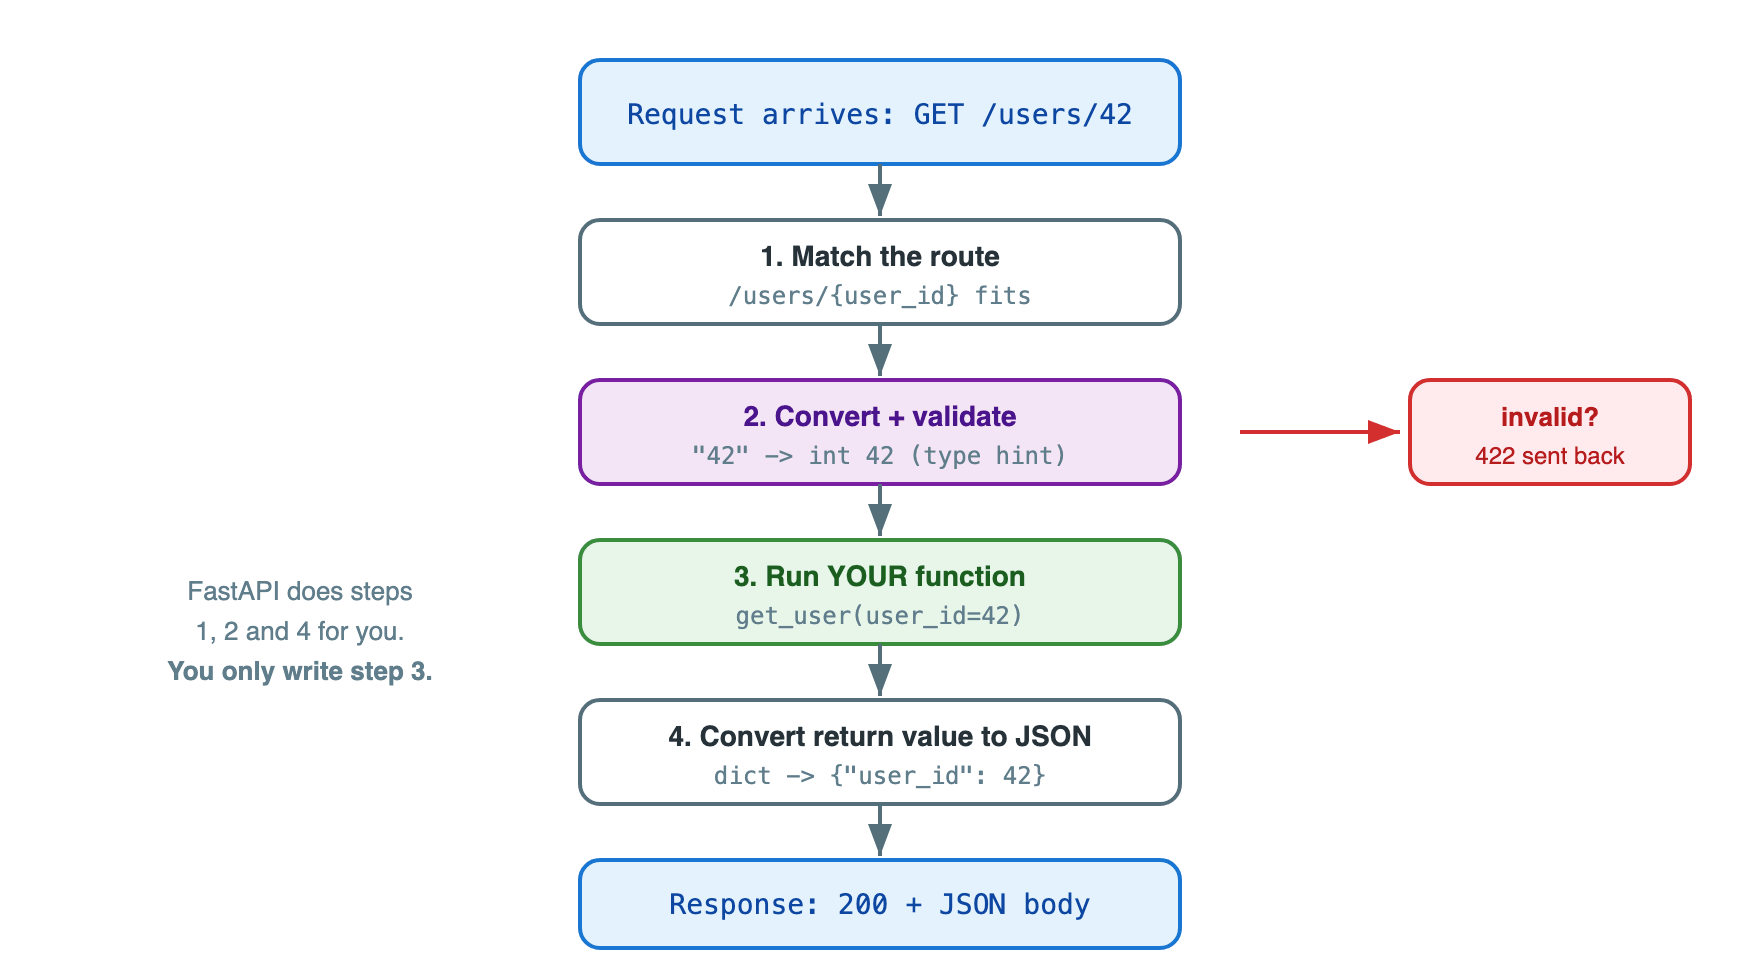

To run this for real you would save the code to `main.py` and run `uvicorn main:app --reload` in a terminal. In the notebook, `TestClient` plays the role of the browser.

In [ ]:
from fastapi import FastAPI
from fastapi.testclient import TestClient

app = FastAPI()                      # 1. create the app

@app.get("/")                        # 2. route: GET / -> this function
def read_root():
    return {"message": "Hello, API world!"}   # 3. dict -> JSON, automatically

# TestClient sends requests straight to the app - no server needed
client = TestClient(app)

response = client.get("/")
print("Status code:", response.status_code)
print("Body:", response.json())

**What just happened:** `client.get("/")` played the part of a browser. FastAPI matched the path `/`, called `read_root()`, converted the returned dict to JSON, and set the status code to 200. Four lines of code = a working API.

**Try it:** add a second endpoint `@app.get("/about")` returning your name, re-run the cell, and request it with `client.get("/about")`.

## Part 4: Path Parameters

Real APIs need addresses that contain **variables**: `/users/42`, `/products/15`. In FastAPI you:

1. Put the variable part of the path in curly braces: `"/users/{user_id}"`.
2. Declare a function argument **with the same name**: `def get_user(user_id: int)`.
3. Give it a **type hint** — this is not decoration! FastAPI uses it to convert the text from the URL (`"42"`) into a real `int`, and to **reject** requests where conversion fails.

Watch both the success case and the failure case:

In [2]:
app = FastAPI()

@app.get("/users/{user_id}")
def get_user(user_id: int):
    return {"user_id": user_id, "type": str(type(user_id))}

client = TestClient(app)

# The "42" in the URL is text, but FastAPI converts it to int because of the type hint
print(client.get("/users/42").json())

# A non-integer is rejected automatically with 422
bad = client.get("/users/not-a-number")
print("Status:", bad.status_code)
print("Error:", bad.json()["detail"][0]["msg"])

NameError: name 'FastAPI' is not defined

**What just happened:** for `/users/42`, FastAPI converted `"42"` → `42` before your function ran (step 2 in the lifecycle diagram). For `/users/not-a-number`, conversion failed, so FastAPI **never called your function** — it immediately answered with status 422 and a message explaining the problem. You get input validation for free, just by writing type hints.

## Part 5: Query Parameters

Not everything belongs in the path. Options like *how many results*, *what filter*, *what sort order* go after the `?` as **query parameters**. Compare the two kinds:

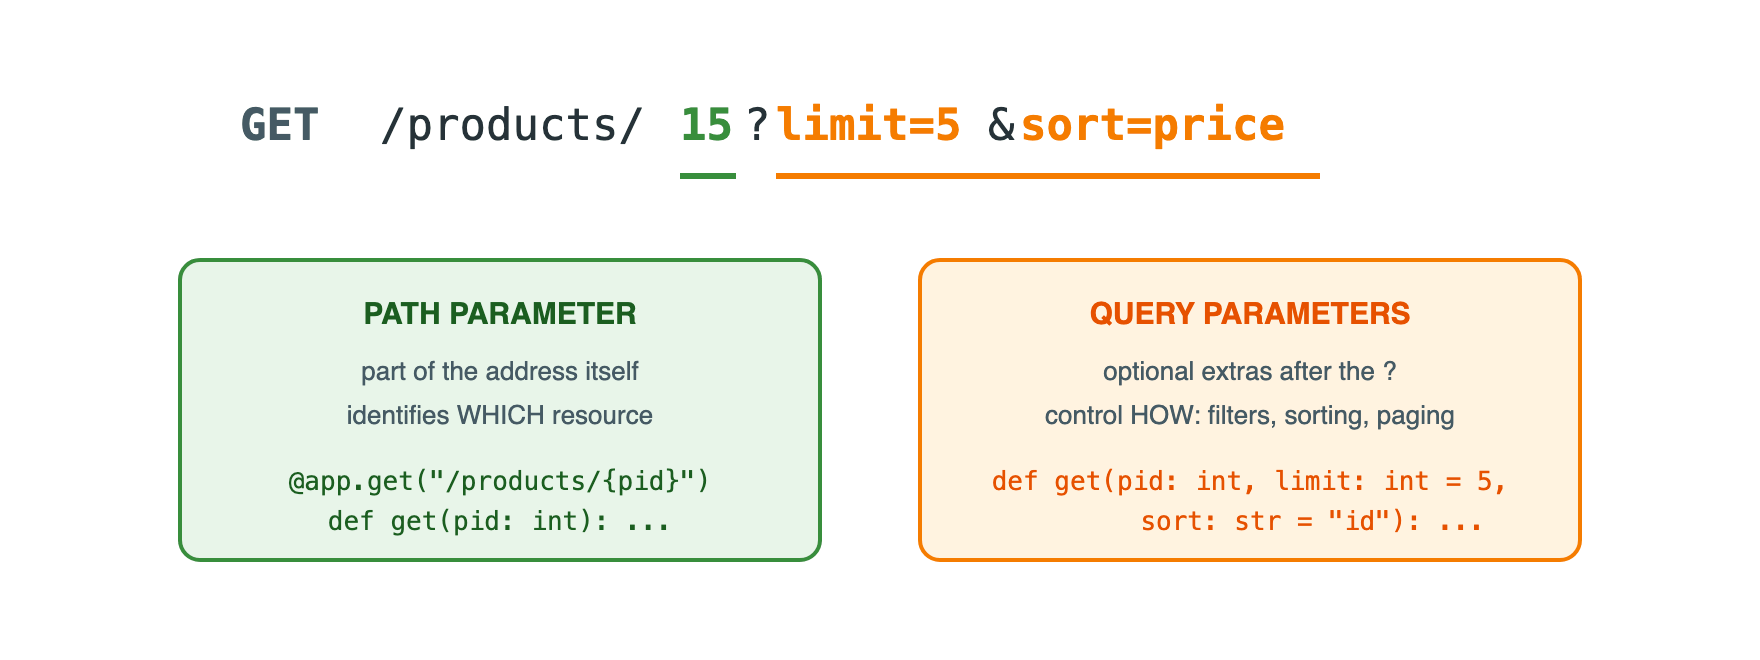

The FastAPI rule is simple:

1. A function argument that **is** in the path template → path parameter.
2. A function argument that **is not** in the path template → query parameter.
3. Give it a default value → optional. No default → required (missing it = 422).

In [ ]:
app = FastAPI()

@app.get("/search")
def search(q: str, limit: int = 10, exact: bool = False):
    return {"query": q, "limit": limit, "exact": exact}

client = TestClient(app)

# 'q' is required; 'limit' and 'exact' fall back to their defaults
print(client.get("/search?q=fastapi").json())

# Provide everything - note "true" becomes Python True
print(client.get("/search?q=fastapi&limit=3&exact=true").json())

# Missing required parameter -> 422
print("Missing q:", client.get("/search").status_code)

**What just happened:** `q` had no default, so it was required. `limit` and `exact` had defaults, so the first request could omit them. In the second request, FastAPI converted the text `"3"` to the int `3` and `"true"` to `True` — same type-hint magic as path parameters.

## Part 6: Request Bodies with Pydantic

GET requests carry all their information in the URL. But when a client **creates** something — a user signs up, an order is placed — it sends a chunk of JSON in the request **body**. Your job as the API author is to say exactly what that JSON must look like. You do it with a **Pydantic model**:

1. **Define a class** inheriting from `BaseModel`.
2. **Declare each field with a type** — `username: str`. Fields with defaults are optional.
3. **Use the model as a parameter type** in a POST endpoint: `def signup(payload: SignupRequest)`.

FastAPI then guards the door for you:

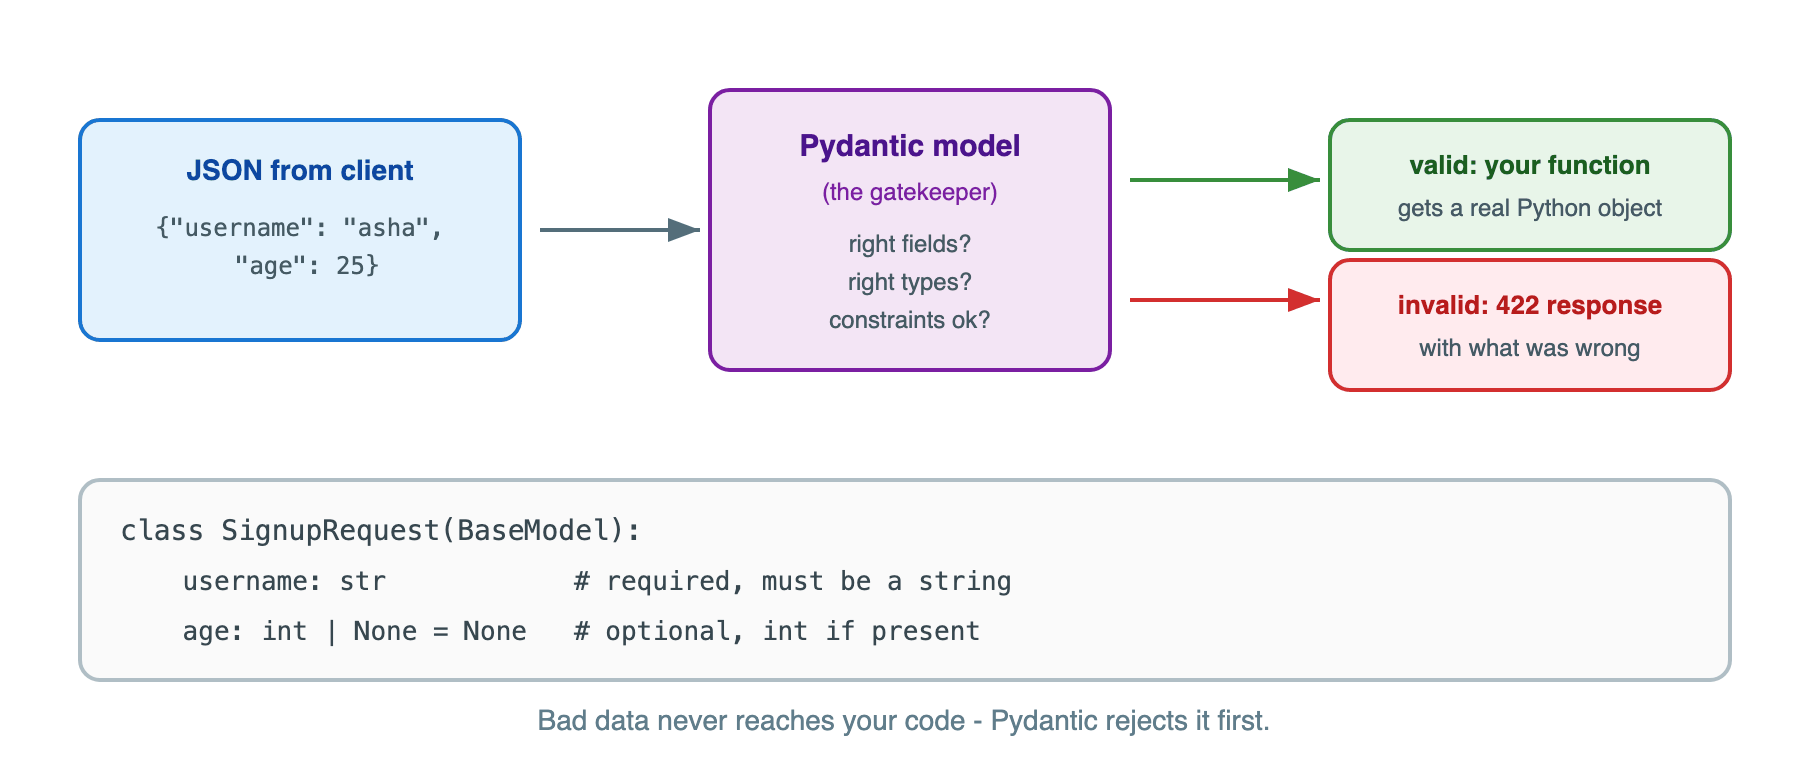

In [ ]:
from pydantic import BaseModel

class SignupRequest(BaseModel):
    username: str
    email: str
    age: int | None = None   # optional field

app = FastAPI()

@app.post("/signup")
def signup(payload: SignupRequest):
    # payload is a real Python object, already validated
    return {"welcome": payload.username, "has_age": payload.age is not None}

client = TestClient(app)

# Valid body
ok = client.post("/signup", json={"username": "asha", "email": "asha@example.com"})
print(ok.status_code, ok.json())

# Invalid body: age is not an int -> automatic 422 with a helpful message
bad = client.post("/signup", json={"username": "asha", "email": "a@b.com", "age": "old"})
print(bad.status_code, bad.json()["detail"][0]["msg"])

**What just happened:** the first request matched the model, so `signup()` received a real `SignupRequest` object — note the attribute access `payload.username`, not dict access. The second request had `"age": "old"`, which can't become an `int`, so FastAPI answered 422 **before your function ran**, and the error message named the exact field and problem. This is FastAPI's superpower: invalid data never reaches your code.

**Try it:** remove `email` from the first request's JSON and re-run — required field missing, 422.

## Part 7: Status Codes and Errors

So far every success was a 200 and we never signaled failure ourselves. Real APIs are more precise. Two tools:

1. **`status_code=...` on the decorator** — sets the success code. Use `201` ("Created") for successful POST-creation.
2. **`raise HTTPException(status_code=..., detail=...)`** — aborts the request and sends an error response. Use it when the request is well-formed but can't be fulfilled: the item doesn't exist (404), the user isn't allowed (403), etc.

Note that you `raise` an HTTPException like any Python exception — the function stops right there, nothing after it runs.

In [ ]:
from fastapi import HTTPException

app = FastAPI()

FAKE_DB = {1: "Learn HTTP", 2: "Learn FastAPI"}

@app.get("/tasks/{task_id}")
def get_task(task_id: int):
    if task_id not in FAKE_DB:
        raise HTTPException(status_code=404, detail=f"Task {task_id} not found")
    return {"id": task_id, "title": FAKE_DB[task_id]}

@app.post("/tasks", status_code=201)
def create_task(payload: dict):
    return {"created": True, "title": payload.get("title")}

client = TestClient(app)

print(client.get("/tasks/1").status_code, client.get("/tasks/1").json())
print(client.get("/tasks/99").status_code, client.get("/tasks/99").json())
print(client.post("/tasks", json={"title": "Ship it"}).status_code)

**What just happened:** task 1 exists → 200 with data. Task 99 doesn't → the `raise` fired and the client got `404` with `{"detail": "Task 99 not found"}`. The POST returned 201 because we declared it on the decorator.

## Part 8: Putting It Together — A CRUD API

**CRUD** = Create, Read, Update, Delete — the four operations almost every API offers. Here is the classic mapping for a todo service:

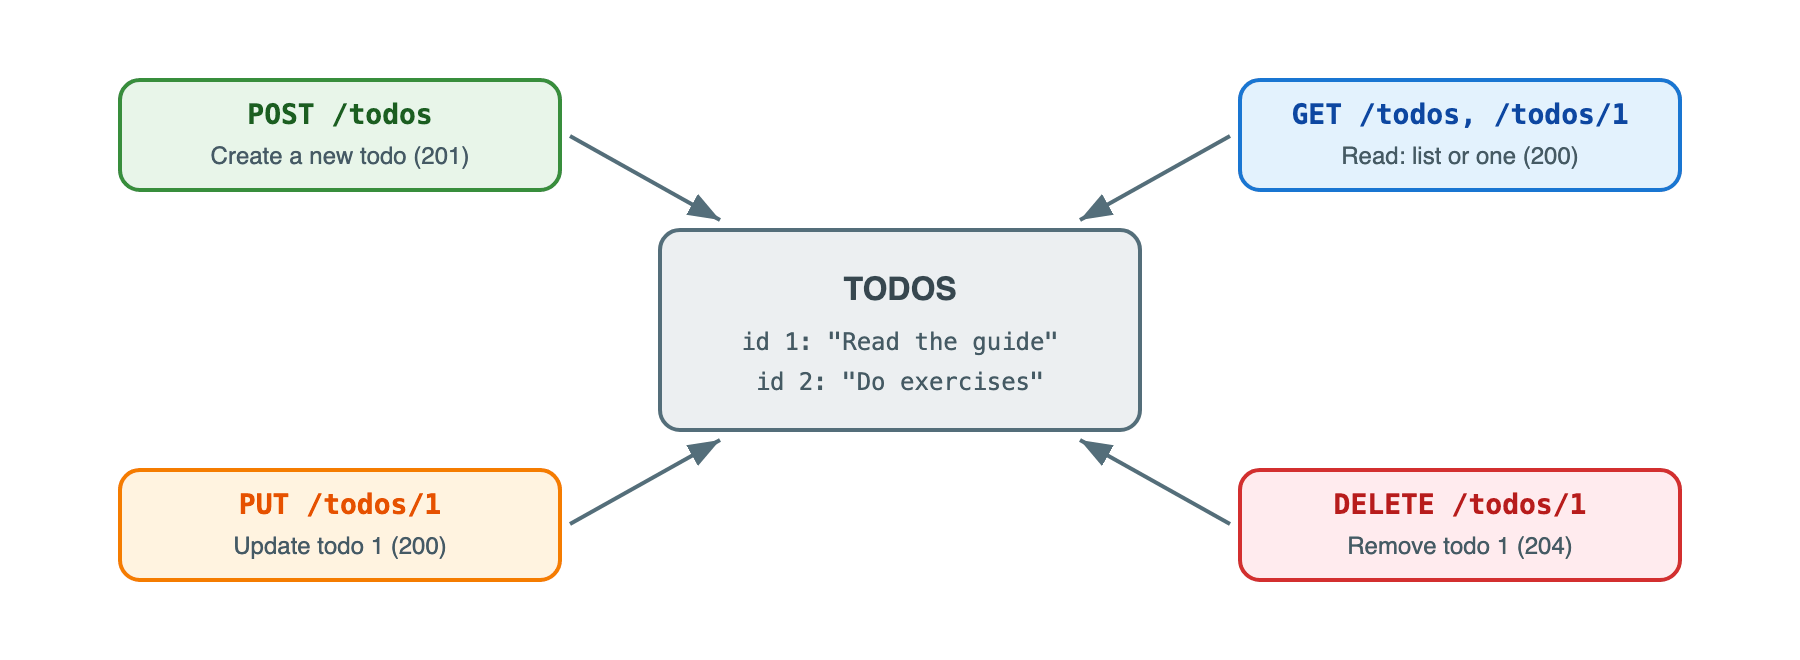

We'll build it with everything from Parts 3–7. Read the code top to bottom with this plan:

1. **The model** (`TodoIn`) — what a client must send to create/update a todo.
2. **The storage** — a plain dict `{id: todo}` plus a counter for the next id. (A real app would use a database — that's in the intermediate guide.)
3. **Five endpoints** — one per arrow in the diagram above. Notice how each one is just a small combination of things you already know: path params, query params, a Pydantic body, `HTTPException`, `status_code`.

In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

class TodoIn(BaseModel):
    title: str
    done: bool = False

app = FastAPI()

todos: dict[int, dict] = {}   # our "database": {id: {"title": ..., "done": ...}}
next_id = 1

@app.post("/todos", status_code=201)
def create_todo(todo: TodoIn):
    global next_id
    todos[next_id] = todo.model_dump()
    result = {"id": next_id, **todos[next_id]}
    next_id += 1
    return result

@app.get("/todos")
def list_todos(done: bool | None = None):
    items = [{"id": i, **t} for i, t in todos.items()]
    if done is not None:                      # optional filter: /todos?done=true
        items = [t for t in items if t["done"] == done]
    return items

@app.get("/todos/{todo_id}")
def get_todo(todo_id: int):
    if todo_id not in todos:
        raise HTTPException(status_code=404, detail="Todo not found")
    return {"id": todo_id, **todos[todo_id]}

@app.put("/todos/{todo_id}")
def update_todo(todo_id: int, todo: TodoIn):
    if todo_id not in todos:
        raise HTTPException(status_code=404, detail="Todo not found")
    todos[todo_id] = todo.model_dump()
    return {"id": todo_id, **todos[todo_id]}

@app.delete("/todos/{todo_id}", status_code=204)
def delete_todo(todo_id: int):
    if todo_id not in todos:
        raise HTTPException(status_code=404, detail="Todo not found")
    del todos[todo_id]

print("App defined with", len(app.routes), "routes")

A few details worth pausing on:

- **`todo.model_dump()`** converts a Pydantic object back into a plain dict so we can store it.
- **`{"id": next_id, **todos[next_id]}`** merges the id into the stored dict for the response — clients need to know the id we assigned.
- **`update_todo` takes both** a path parameter (`todo_id` — which todo) and a body (`todo` — the new content). FastAPI figures out which is which from the path template and the types.
- **DELETE returns 204 ("No Content")** — success with an empty body, the convention for deletions.

Now let's use the API the way a client would — one operation at a time:

In [ ]:
# Take the CRUD API for a spin
client = TestClient(app)

# Create
r1 = client.post("/todos", json={"title": "Read the guide"})
r2 = client.post("/todos", json={"title": "Do the exercises", "done": True})
print("Created:", r1.json(), r2.json())

# Read (all, then filtered, then one)
print("All:", client.get("/todos").json())
print("Done only:", client.get("/todos?done=true").json())
print("One:", client.get("/todos/1").json())

# Update
print("Updated:", client.put("/todos/1", json={"title": "Read the guide", "done": True}).json())

# Delete
print("Delete status:", client.delete("/todos/2").status_code)
print("After delete:", client.get("/todos").json())
print("Gone:", client.get("/todos/2").status_code)

**Follow the output line by line** and match each print to the endpoint that served it. This create → read → update → delete sequence is the heartbeat of nearly every web application you have ever used.

## Part 9: Running It for Real + Free Interactive Docs

Time to leave the notebook. To serve this API over the network:

1. Create a file `main.py` and paste the CRUD app code into it (everything except the `TestClient` parts).
2. Open a terminal in that folder and run: `uvicorn main:app --reload`
   - `main` = the file `main.py`, `app` = the variable inside it, `--reload` = restart automatically when you edit the file.
3. Open `http://localhost:8000/todos` in your browser — that's your API responding.
4. Now open `http://localhost:8000/docs`:

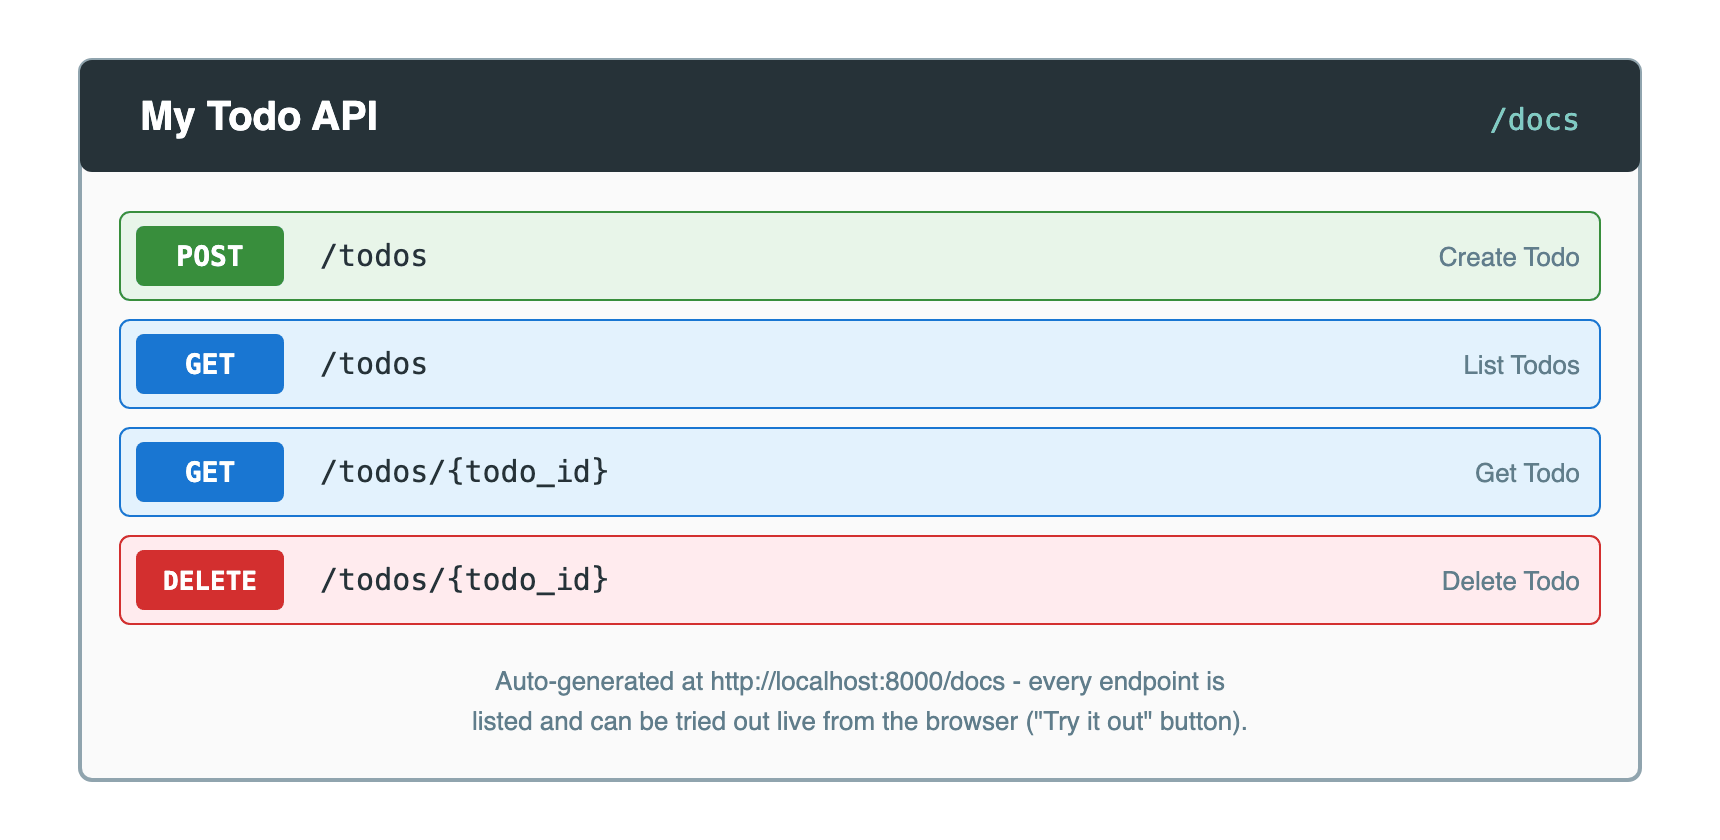

FastAPI **generated this documentation page from your code** — every endpoint, every parameter, every model, with a "Try it out" button that sends real requests. You wrote zero extra lines for it. There is also an alternative view at `/redoc`.

Both pages are rendered from the **OpenAPI schema** — a machine-readable JSON description of your API that FastAPI derives from your functions and type hints. Let's peek at it:

In [ ]:
# The same schema that powers /docs - generated from your functions and type hints
schema = client.get("/openapi.json").json()
print("API title:", schema["info"]["title"])
print("Endpoints:")
for path, methods in schema["paths"].items():
    print(" ", path, "->", ", ".join(m.upper() for m in methods))

## Recap

You now know the core of every web API:

- **HTTP**: URLs (scheme/domain/path/query), methods (GET/POST/PUT/DELETE), status codes (2xx/4xx/5xx), JSON
- **Calling APIs** with `requests`: send, check status, parse JSON
- **Building APIs** with FastAPI: routing, path parameters, query parameters, Pydantic request bodies
- **Errors** with `HTTPException` and precise status codes
- A full **CRUD** service, and the auto-generated `/docs`

Next: work through `api-basics-exercises.ipynb`, then continue to the `api-intermediate` material (validation in depth, routers, dependencies, auth, middleware, databases, and testing).